In [1]:
import pandas as pd

In [2]:
import pickle

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error
import mlflow 

/opt/conda/envs/exp-tracking-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("newyc-taxi-experiment")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1782316164012, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782316164012, lifecycle_stage='active', name='newyc-taxi-experiment', tags={}, trace_location=None, workspace='default'>

In [6]:
# Charger le CSV en convertissant directement les dates
df = pd.read_csv(
    'green_tripdata_2021-01.csv',
    parse_dates=['lpep_pickup_datetime', 'lpep_dropoff_datetime']
)

# Calcul de la durée en minutes
df['duration'] = (
    df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']
).dt.total_seconds() / 60

# Garder uniquement les trajets entre 1 et 60 minutes
df = df[(df['duration'] >= 1) & (df['duration'] <= 60)]

# Colonnes utilisées
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

# Conversion des variables catégoriques en chaînes de caractères
df[categorical] = df[categorical].astype(str)

# Vérification
df.head()

df.head()

/tmp/ipykernel_115674/403527905.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,...,0.5,0.00,0.0,NaN,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,...,0.5,2.81,0.0,NaN,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,...,0.5,1.00,0.0,NaN,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,...,0.5,0.00,0.0,NaN,0.3,9.30,2.0,1.0,0.00,7.083333
7,2,2021-01-01 00:26:31,2021-01-01 00:28:50,N,1.0,75,75,6.0,0.45,3.5,...,0.5,0.96,0.0,NaN,0.3,5.76,1.0,1.0,0.00,2.316667


In [7]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

9.838799799829626

/tmp/ipykernel_115674/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_115674/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


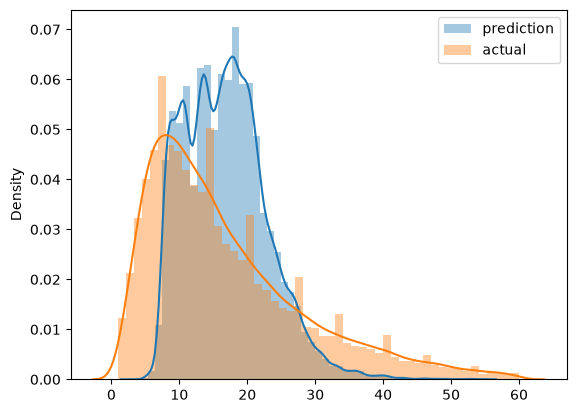

In [8]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [9]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [10]:
df_train = read_dataframe('green_tripdata_2021-01.csv')
df_val = read_dataframe('green_tripdata_2021-02.csv')

/tmp/ipykernel_115674/722539646.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


In [11]:
len(df_train), len(df_val)

(73908, 61921)

In [12]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [13]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [14]:
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

X_train.indices = X_train.indices.astype('int32')
X_train.indptr = X_train.indptr.astype('int32')

X_val.indices = X_val.indices.astype('int32')
X_val.indptr = X_val.indptr.astype('int32')

In [15]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.758715209092169

In [17]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [18]:
with mlflow.start_run():

    mlflow.set_tag("developer", "chakirou")

    mlflow.log_param("train-data-path", "green_tripdata_2021-01.csv")
    mlflow.log_param("valid-data-path", "green_tripdata_2021-02.csv")

    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")

🏃 View run righteous-finch-306 at: http://localhost:5000/#/experiments/1/runs/e12b956c39b24ee9bfcd73c0666d592e
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [19]:
import xgboost as xgb

In [20]:

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope
import pkg_resources

/opt/conda/envs/exp-tracking-env/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [21]:

train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [22]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")

        params['objective'] = 'reg:squarederror'

        mlflow.log_params(params)

        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=100,  # au lieu de 1000 pour tester
            evals=[(valid, 'validation')],
            early_stopping_rounds=20
        )

        y_pred = booster.predict(valid)

        rmse = root_mean_squared_error(
            y_val,
            y_pred,
            
        )

        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [23]:

search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 20, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:squarederror',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=4,
    trials=Trials()
)

[0]	validation-rmse:11.66698                         
[1]	validation-rmse:11.16949                         
[2]	validation-rmse:10.71753                         
[3]	validation-rmse:10.30765                         
[4]	validation-rmse:9.93647                          
[5]	validation-rmse:9.60131                          
[6]	validation-rmse:9.29871                          
[7]	validation-rmse:9.02588                          
[8]	validation-rmse:8.78146                          
[9]	validation-rmse:8.56205                          
[10]	validation-rmse:8.36533                         
[11]	validation-rmse:8.18986                         
[12]	validation-rmse:8.03241                         
[13]	validation-rmse:7.89187                         
[14]	validation-rmse:7.76662                         
[15]	validation-rmse:7.65511                         
[16]	validation-rmse:7.55667                         
[17]	validation-rmse:7.46815                         
[18]	validation-rmse:7.39011

In [24]:

mlflow.xgboost.autolog(disable=True)

In [ ]:
with mlflow.start_run():
    
    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)

    best_params = {
        'learning_rate': 0.09585355369315604,
        'max_depth': 30,
        'min_child_weight': 1.060597050922164,
        'objective': 'reg:linear',
        'reg_alpha': 0.018060244040060163,
        'reg_lambda': 0.011658731377413597,
        'seed': 42
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )

    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)
    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

/opt/conda/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [17:30:16] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:11.44174
[1]	validation-rmse:10.76627
[2]	validation-rmse:10.17716
[3]	validation-rmse:9.66439
[4]	validation-rmse:9.21865
[5]	validation-rmse:8.83455
[6]	validation-rmse:8.50406
[7]	validation-rmse:8.22010
[8]	validation-rmse:7.97540
[9]	validation-rmse:7.76692
[10]	validation-rmse:7.58908
[11]	validation-rmse:7.43668
[12]	validation-rmse:7.30705
[13]	validation-rmse:7.19678
[14]	validation-rmse:7.10367
[15]	validation-rmse:7.02340
[16]	validation-rmse:6.95494
[17]	validation-rmse:6.89584
[18]	validation-rmse:6.84617
[19]	validation-rmse:6.80219
[20]	validation-rmse:6.76453
[21]	validation-rmse:6.73295
[22]	validation-rmse:6.70496
[23]	validation-rmse:6.68006
[24]	validation-rmse:6.65942
[25]	validation-rmse:6.64052
[26]	validation-rmse:6.62474
[27]	validation-rmse:6.61037
[28]	validation-rmse:6.59772
[29]	validation-rmse:6.58649
[30]	validation-rmse:6.57661
[31]	validation-rmse:6.56756
[32]	validation-rmse:6.55900
[33]	validation-rmse:6.55050
[34]	validation-rmse:

2026/06/24 17:33:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run vaunted-kite-314 at: http://localhost:5000/#/experiments/1/runs/0adf65b932d9471cb6a33d61ddb6d9c5
🧪 View experiment at: http://localhost:5000/#/experiments/1


: 

In [ ]:

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
mlflow.sklearn.autolog()

for model_class in (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor):

    with mlflow.start_run():

        mlflow.log_param("train-data-path", "green_tripdata_2021-01.csv")
        mlflow.log_param("valid-data-path", "green_tripdata_2021-02.csv")
        mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

        mlmodel = model_class()
        mlmodel.fit(X_train, y_train)

        y_pred = mlmodel.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)
        